# ¿Cuál es la motivación para este análisis?
##### NOTA: Los datos trabajados en este portafolio son de carácter público, se encuentra de acceso libre en la página del MinTic de Colombia
##### Se plantearon las siguientes preguntas que permitirán conocer cuál es el contexto que vive Colombia en cuanto uso y cobertura de telefonía móvil y fija, respuesta que nos dará el modelado y visualización de los datos.

<ol>
<li>¿Qué operador tiene más abonados (usuarios) de internet móvil en Colombia?</li>
<li>¿Cómo evolucionó el tráfico de datos móviles por proveedor 2023-2025?</li>
<li>¿Qué municipios tienen menor cobertura de servicio móvil?</li>
<li>¿Relación entre líneas móviles e ingresos por proveedor?</li>
<li>¿Qué departamentos concentran mayor brecha digital en acceso fijo?</li>
</ol>

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [24]:
df_accesos_fijos = pd.read_csv("../data/processed/accesos_fijos.csv")
df_abonados_moviles = pd.read_csv("../data/processed/abonados_moviles.csv")
df_trafico_movil = pd.read_csv("../data/processed/trafico_movil.csv")
df_lineas_moviles = pd.read_csv("../data/processed/lineas_moviles.csv")
df_ingresos_por_voz = pd.read_csv("../data/processed/ingresos_por_voz.csv")
df_cobertura_movil_por_municipio = pd.read_csv("../data/processed/cobertura_movil_por_municipio.csv")

#### Las columnas de tecnología en la tabla Cobertura movil por municipio deben pasar a tipo Booleano
##### Esto es para que ocupe menos espacio en memoria y sea mejor el procesamiento. 

In [25]:
#Conversión de tipo de dato STR a BOOLEAN
df_cobertura_movil_por_municipio.dtypes
columnas_cobertura = ["2G","3G","HSPA+","4G","LTE","5G"]

for col in columnas_cobertura:
    df_cobertura_movil_por_municipio[col] = df_cobertura_movil_por_municipio[col].map({"S": True, "N":False})

In [ ]:
#Corroboramos cambios
df_cobertura_movil_por_municipio.dtypes
print(df_cobertura_movil_por_municipio.head())

## 1. ¿Qué operador tiene más abonados (usuarios) de internet móvil en Colombia?
##### Para esta pregunta, tabajaremos con abonados_moviles.csv

In [68]:
print(df_abonados_moviles.head(20))

     AÑO  TRIMESTRE                                PROVEEDOR SEGMENTO  \
0   2023          2       ALMACENES EXITO INVERSIONES S.A.S.  PREPAGO   
1   2023          2       ALMACENES EXITO INVERSIONES S.A.S.  PREPAGO   
2   2023          2                  COLOMBIA MOVIL  S.A ESP  POSPAGO   
3   2023          2                  COLOMBIA MOVIL  S.A ESP  POSPAGO   
4   2023          2                  COLOMBIA MOVIL  S.A ESP  POSPAGO   
5   2023          2                  COLOMBIA MOVIL  S.A ESP  POSPAGO   
6   2023          2                  COLOMBIA MOVIL  S.A ESP  PREPAGO   
7   2023          2                  COLOMBIA MOVIL  S.A ESP  PREPAGO   
8   2023          2                  COLOMBIA MOVIL  S.A ESP  PREPAGO   
9   2023          2                  COLOMBIA MOVIL  S.A ESP  PREPAGO   
10  2023          2  COLOMBIA TELECOMUNICACIONES S.A. E.S.P.  POSPAGO   
11  2023          2  COLOMBIA TELECOMUNICACIONES S.A. E.S.P.  POSPAGO   
12  2023          2  COLOMBIA TELECOMUNICACIONES S.

### La siguiente gráfica no es la definitiva
#### Posterior a esta gráfica se mostrará cómo mejorar la visualización, para que sea más clara, filtrada y nos dé un mejor insight

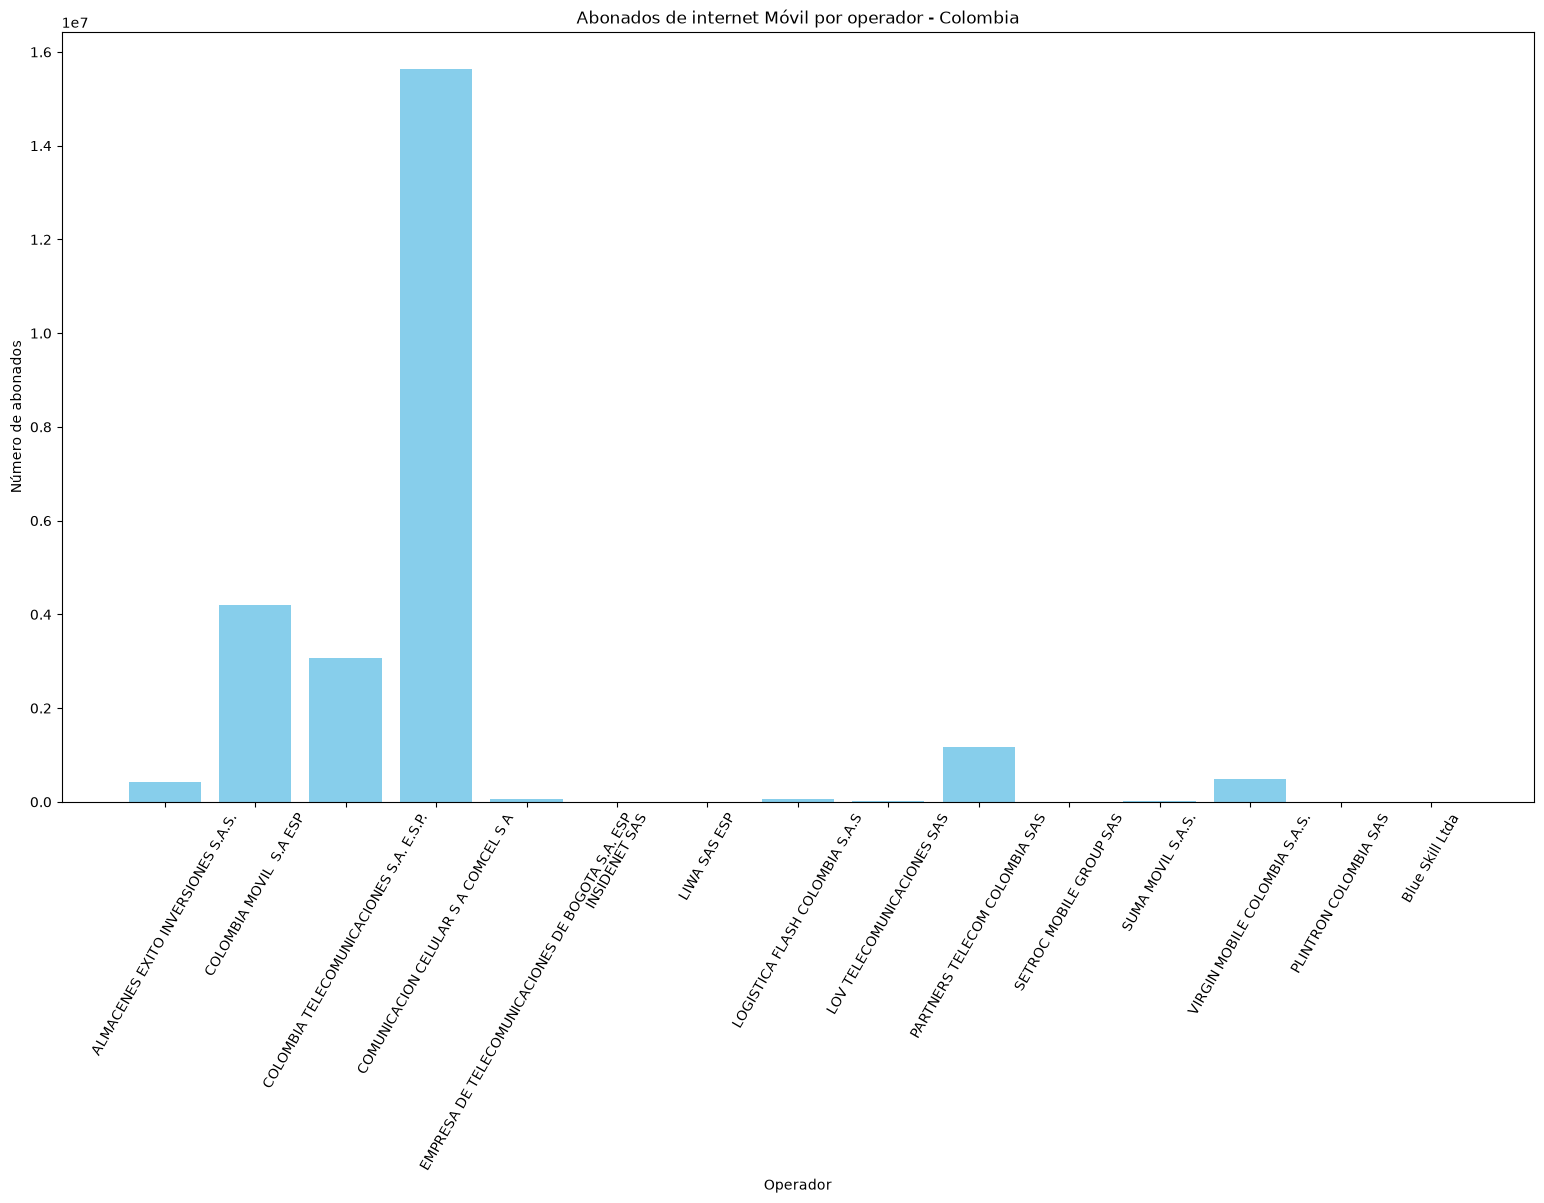

In [48]:
plt.figure(figsize=(19,10))
plt.bar(df_abonados_moviles["PROVEEDOR"], 
        df_abonados_moviles["No. ABONADOS"],
        color='skyblue', label='Número de abonados')
plt.title('Abonados de internet Móvil por operador - Colombia')
plt.xlabel('Operador')
plt.ylabel('Número de abonados')
plt.xticks(rotation=60)
df_abonadosplt.show()

In [118]:
#Filtro para el año 2025 trimestre 4 (Registros más recientes)
df_abonados_moviles_filtro = df_abonados_moviles[
    (df_abonados_moviles["AÑO"] == 2025) & 
    (df_abonados_moviles["TRIMESTRE"] == 4) &
    (df_abonados_moviles["TERMINAL"]== "TELÉFONO MÓVIL")
]

#DataFrame para Abonados tipo PREPAGO
df_abonados_prep = df_abonados_moviles_filtro[
    df_abonados_moviles_filtro["SEGMENTO"] == "PREPAGO"
]

#DataFrame para Abonados tipo POSPAGO
df_abonados_pos = df_abonados_moviles_filtro[
    df_abonados_moviles_filtro["SEGMENTO"] == "POSPAGO"
]

In [119]:
#Pivot para organizar por PROVEEDOR y por tecnología
pivot_pre = df_abonados_prep.pivot_table(
    index="PROVEEDOR",
    columns="TECNOLOGÍA",
    values="No. ABONADOS",
    aggfunc="sum",
    fill_value=0
)

pivot_pos = df_abonados_pos.pivot_table(
    index="PROVEEDOR",
    columns="TECNOLOGÍA",
    values="No. ABONADOS",
    aggfunc="sum",
    fill_value=0
)

In [120]:
#Organizando de mayor a menor

pivot_pre['TOTAL'] = pivot_pre.sum(axis=1)
pivot_pre = pivot_pre.sort_values('TOTAL', ascending = False)
pivot_pre = pivot_pre.drop(columns = 'TOTAL')

pivot_pos['TOTAL'] = pivot_pre.sum(axis=1)
pivot_pos = pivot_pos.sort_values('TOTAL', ascending = False)
pivot_pos = pivot_pos.drop(columns = 'TOTAL')

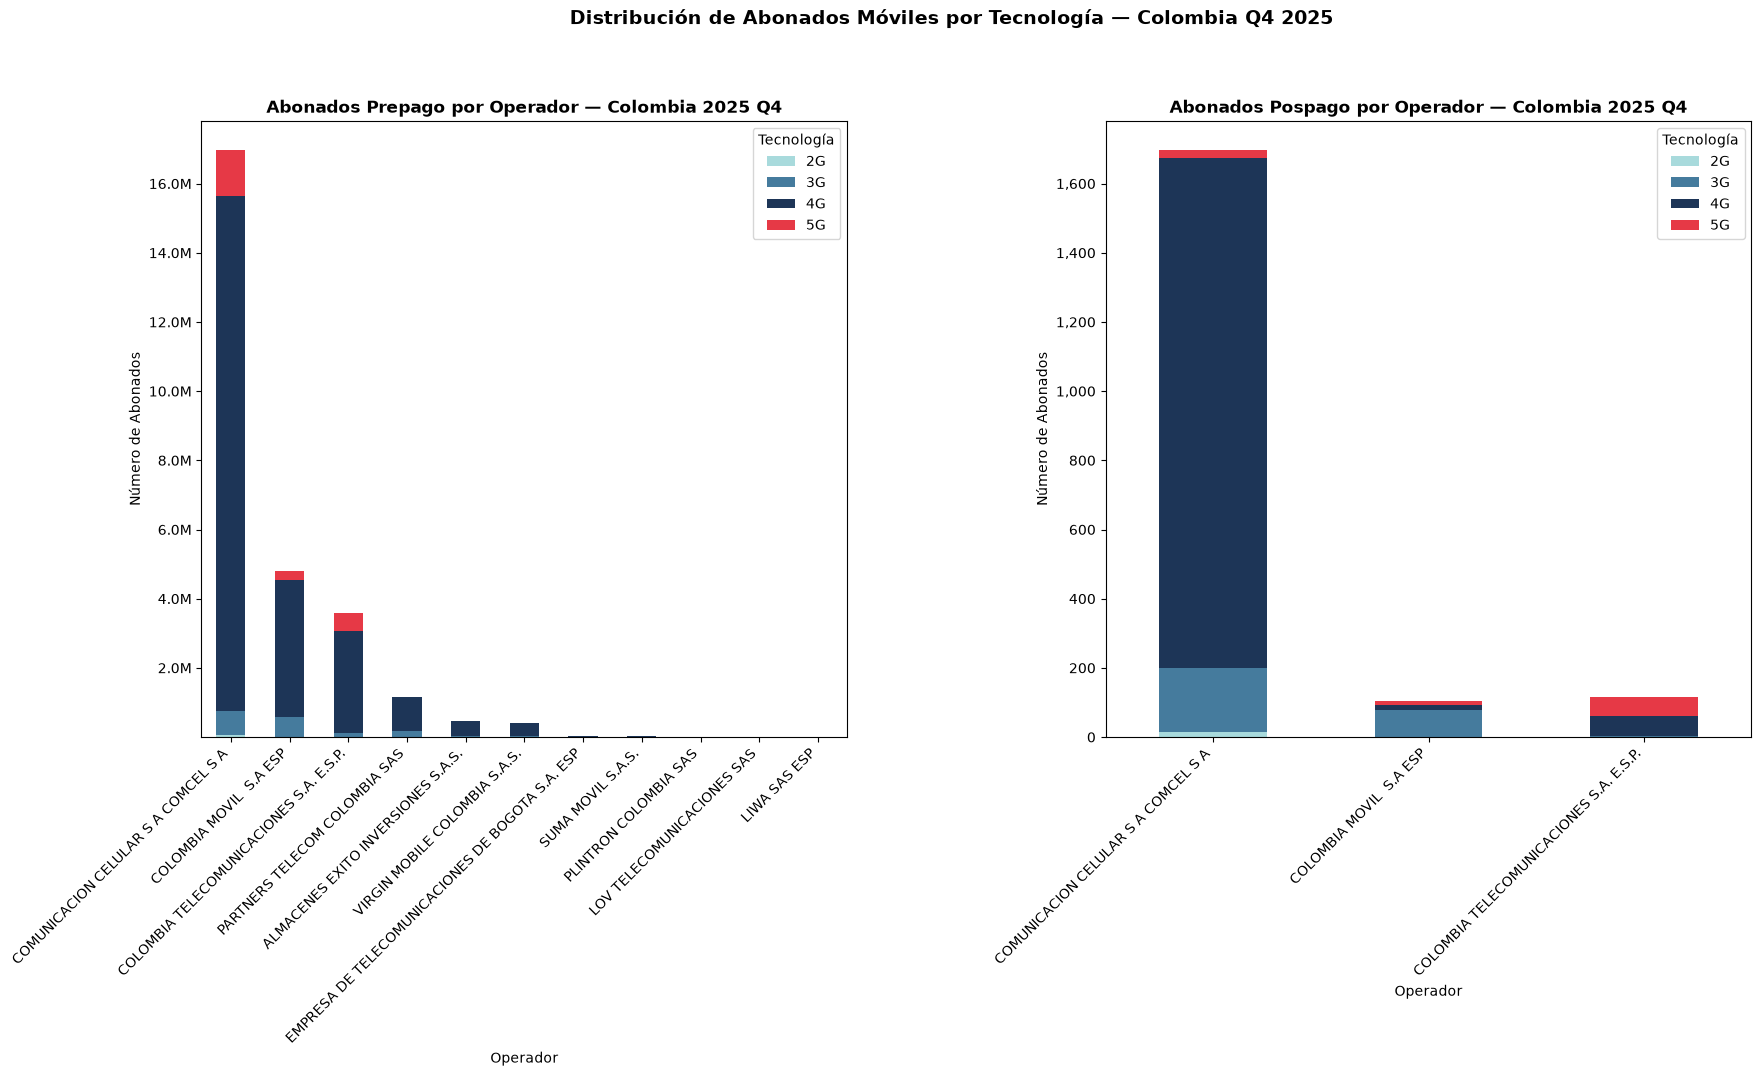

In [149]:
# Paleta de colores por tecnología
colores = {
    "2G": "#A8DADC",
    "3G": "#457B9D", 
    "4G": "#1D3557",
    "5G": "#E63946"
}

# Formatter para eje Y
formatter = mticker.FuncFormatter(
    lambda x, _: f"{x/1_000_000:.1f}M" if x >= 1_000_000 else f"{x:,.0f}"
)

# Crear subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Prepago
pivot_pre.plot(kind="bar", stacked=True, ax=ax1, 
               color=[colores.get(col, "gray") for col in pivot_pre.columns])
ax1.set_title("Abonados Prepago por Operador — Colombia 2025 Q4", fontsize=12, fontweight="bold")
ax1.legend(title="Tecnología")
ax1.set_xlabel("Operador", fontsize=10)
ax1.set_ylabel("Número de Abonados", fontsize=10)
ax1.yaxis.set_major_formatter(formatter)
ax1.tick_params(axis="x", rotation=45)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")


# Pospago
pivot_pos.plot(kind="bar", stacked=True, ax=ax2,
               color=[colores.get(col, "gray") for col in pivot_pos.columns])
ax2.set_title("Abonados Pospago por Operador — Colombia 2025 Q4", fontsize=12, fontweight="bold")
ax2.legend(title="Tecnología")
ax2.set_xlabel("Operador", fontsize=10)
ax2.set_ylabel("Número de Abonados", fontsize=10)
ax2.yaxis.set_major_formatter(formatter)
ax2.tick_params(axis="x", rotation=45)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")


fig.suptitle("Distribución de Abonados Móviles por Tecnología — Colombia Q4 2025", 
             fontsize=14, fontweight="bold", y=1.02)

plt.subplots_adjust(wspace=0.4)
plt.show()